# Analisis Sentimen Ulasan Pengguna — Adobe Lightroom Mobile

**Ringkasan:** notebook ini menganalisis sentimen ulasan pengguna aplikasi Adobe Lightroom
Mobile di Google Play Store (ulasan berbahasa Indonesia). Karena tidak ada label sentimen
manual, label dibuat otomatis menggunakan model **IndoBERT/IndoRoBERTa** yang sudah dilatih
untuk sentimen Bahasa Indonesia. Label tersebut lalu dipakai untuk melatih & membandingkan
beberapa model klasifikasi — **Naive Bayes, SVM, Random Forest**, dan **BiLSTM** — yang
akhirnya digabung jadi satu **ensemble model**.

**Alur notebook:**
1. Scraping ulasan dari Google Play Store
2. Preprocessing teks (minimal, disesuaikan untuk BERT)
3. Pelabelan otomatis sentimen dengan IndoBERT
4. Penyeimbangan kelas
5. Split data & ekstraksi fitur TF-IDF
6. Model Machine Learning (Naive Bayes, SVM, Random Forest)
7. Model Deep Learning (BiLSTM)
8. Evaluasi & analisis overfitting
9. Ensemble model
10. Ringkasan hasil
11. Word cloud
12. Demo prediksi

> **Catatan penyederhanaan dari notebook asli:** kode dipangkas (cell duplikat serta
> import/logic yang tidak terpakai dihapus), dan `app_id` scraping diperbaiki ke
> `com.adobe.lrmobile`. Notebook aslinya sempat memakai id aplikasi lain
> (`com.gojek.partner`) meski judul dan seluruh nama file/variabel di sepanjang notebook
> menyebut Lightroom Mobile — sepertinya tertinggal dari template lain. Cek ulang `APP_ID`
> di cell konfigurasi kalau ternyata bukan ini aplikasi yang dimaksud. Jalankan cell
> berurutan dari atas ke bawah.

## 1. Setup & Konfigurasi

Import seluruh library yang dibutuhkan dan definisikan parameter utama di satu tempat,
supaya mudah diubah tanpa harus mencari-cari di tengah notebook.

In [1]:
import os, re, time, pickle, warnings
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from google_play_scraper import reviews, Sort

import torch
from transformers import pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

for folder in ['data', 'model', 'visualisasi']:
    os.makedirs(folder, exist_ok=True)

# --- Konfigurasi utama: ubah di sini sesuai kebutuhan ---
APP_ID = 'com.adobe.lrmobile'       # Adobe Lightroom Mobile di Google Play Store
APP_NAME = 'Adobe Lightroom Mobile'
TARGET_REVIEWS = 5000               # naikkan kalau ingin dataset lebih besar (lebih lama scraping-nya)
CONFIDENCE_THRESHOLD = 0.6          # ambang confidence label IndoBERT yang dipakai
MAX_PER_CLASS = 1500                # batas atas jumlah sampel per kelas saat balancing
RANDOM_STATE = 42

print("Library siap. Device:", "GPU" if torch.cuda.is_available() else "CPU")

Library siap. Device: CPU


## 2. Pengumpulan Data (Scraping)

Mengambil ulasan terbaru dari Google Play Store dengan pagination (`continuation_token`),
disertai retry sederhana kalau terjadi error jaringan sementara.

In [2]:
def scrape_reviews(app_id, target_count=5000, lang='id', country='id', batch_size=200, max_retries=5):
    """Scraping ulasan Google Play Store dengan pagination + retry sederhana."""
    all_reviews = []
    continuation_token = None
    retries = 0

    with tqdm(total=target_count, desc="Scraping") as pbar:
        while len(all_reviews) < target_count and retries < max_retries:
            try:
                batch, continuation_token = reviews(
                    app_id, lang=lang, country=country,
                    sort=Sort.NEWEST, count=batch_size,
                    continuation_token=continuation_token,
                )
                if not batch:
                    break
                all_reviews.extend(batch)
                pbar.update(len(batch))
                time.sleep(0.5)
                if continuation_token is None:
                    break
            except Exception as e:
                retries += 1
                print(f"Retry {retries}/{max_retries} setelah error: {e}")
                time.sleep(2)

    df = pd.DataFrame(all_reviews[:target_count])
    df = df.drop_duplicates(subset='reviewId').reset_index(drop=True)
    df = df.rename(columns={'at': 'date'})
    return df[['content', 'score', 'date', 'thumbsUpCount', 'reviewId']]


df_raw = scrape_reviews(APP_ID, target_count=TARGET_REVIEWS)
df_raw.to_csv('data/lightroom_raw.csv', index=False, encoding='utf-8')

print(f"Total ulasan terkumpul: {len(df_raw)}")
print(df_raw['score'].value_counts().sort_index())
df_raw.head()

Scraping: 100%|██████████| 5000/5000 [00:39<00:00, 127.40it/s]

Total ulasan terkumpul: 5000
score
1     493
2     153
3     203
4     430
5    3721
Name: count, dtype: int64


,content,score,date,thumbsUpCount,reviewId
0,cakep,5,2026-09-09 20:37:38,0,573f6e5a-e9dc-44fe-9f56-16c91bd336ed
1,jos,4,2026-09-09 14:51:07,0,7382bfcc-090f-4b90-9ebb-f1583ff9b52f
2,"Setelah update, berlanggaan habis, preset pada...",1,2026-09-09 13:26:34,141,56e74fb4-b90f-4e59-8538-9c37338e66de
3,I really hope that there will be additional au...,5,2026-09-09 09:17:18,0,dec4fefb-6522-4510-9740-35933935f116
4,bagus banget sangan membantu sekali,5,2026-09-08 19:09:00,0,2f70eb69-230e-423d-a6bb-feb5a16048f2


## 3. Preprocessing Teks

Cleaning yang **minimal** dengan sengaja — tanpa stemming maupun stopword removal —
karena IndoBERT butuh struktur kalimat & tanda baca untuk memahami konteks. Hanya
normalisasi huruf, penghapusan URL, pengulangan huruf (`bagusss` → `bagus`), dan
sebagian slang umum.

In [3]:
SLANG_DICT = {
    'banget': 'sangat', 'bgt': 'sangat', 'dong': '', 'sih': '', 'deh': '', 'yah': '', 'nya': '',
    'lg': 'lagi', 'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak', 'g': 'tidak',
    'jgn': 'jangan', 'pls': 'tolong', 'thx': 'terima kasih', 'tp': 'tapi', 'bs': 'bisa',
    'sdh': 'sudah', 'udh': 'sudah', 'blm': 'belum', 'dlm': 'dalam', 'utk': 'untuk', 'dg': 'dengan',
    'pd': 'pada', 'yg': 'yang', 'krn': 'karena', 'jd': 'jadi', 'klo': 'kalau', 'kalo': 'kalau',
    'ato': 'atau', 'yaa': 'ya', 'y': 'ya', 'ok': 'oke', 'okey': 'oke',
    'app': 'aplikasi', 'apk': 'aplikasi', 'apps': 'aplikasi',
    'foto2': 'foto', 'poto': 'foto', 'pic': 'foto', 'picnya': 'fotonya',
}

def clean_text_for_indobert(text):
    """Cleaning minimal untuk IndoBERT: tetap pertahankan tanda baca & struktur kalimat."""
    if not isinstance(text, str) or pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s.,!?;:\'\"()\-]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)   # bagusss -> bagus
    text = re.sub(r'\s+', ' ', text).strip()

    words = [SLANG_DICT.get(w, w) for w in text.split()]
    return ' '.join(w for w in words if w)


df_raw['content_clean'] = df_raw['content'].apply(clean_text_for_indobert)
df_raw = df_raw[df_raw['content_clean'].str.split().str.len() >= 3].reset_index(drop=True)

print(f"Data setelah cleaning: {len(df_raw)} ulasan")
df_raw[['content', 'content_clean']].sample(min(3, len(df_raw)), random_state=RANDOM_STATE)

Data setelah cleaning: 2224 ulasan


,content,content_clean
96,astaga saya ga bisa nge ekspor foto saya yg su...,astaga saya tidak bisa nge ekspor foto saya ya...
1401,"yaa baguss, soalnya kalo ngedit fto yg dri cah...","ya baguss, soalnya kalau ngedit fto yang dri c..."
1995,Bgus sx aplikasi nya ☺,bgus sx aplikasi


## 4. Pelabelan Otomatis dengan IndoBERT

Dataset ini tidak punya label sentimen manual, jadi label dibuat dengan model sentimen
Bahasa Indonesia yang sudah dilatih sebelumnya (bukan dilatih dari nol di sini). Ini
berarti kualitas label bergantung pada model tersebut — bukan ground truth manusia.
Hanya prediksi dengan confidence ≥ `CONFIDENCE_THRESHOLD` yang dipakai untuk training.

In [4]:
def load_sentiment_classifier():
    """Load model sentimen Bahasa Indonesia, dengan satu fallback kalau model utama gagal diunduh."""
    device = 0 if torch.cuda.is_available() else -1
    for model_name in [
        "w11wo/indonesian-roberta-base-sentiment-classifier",
        "StevenLimcorn/indonesian-roberta-base-sentiment-classifier",
    ]:
        try:
            clf = pipeline("sentiment-analysis", model=model_name, tokenizer=model_name,
                           device=device, truncation=True, max_length=256)
            print(f"Model dimuat: {model_name} ({'GPU' if device == 0 else 'CPU'})")
            return clf
        except Exception as e:
            print(f"Gagal memuat {model_name}: {e}")
    return None


LABEL_MAP = {
    'positive': 'positif', 'negative': 'negatif', 'neutral': 'netral',
    '1 star': 'negatif', '2 stars': 'negatif', '3 stars': 'netral',
    '4 stars': 'positif', '5 stars': 'positif',
}

def map_label(raw_label):
    raw_label = raw_label.lower()
    for key, sentiment in LABEL_MAP.items():
        if key in raw_label:
            return sentiment
    return 'netral'

def label_sentiments(texts, classifier, batch_size=16):
    sentiments, confidences = [], []
    for i in tqdm(range(0, len(texts), batch_size), desc="Labeling"):
        batch = texts[i:i + batch_size]
        try:
            results = classifier(batch, truncation=True, max_length=256)
            for r in results:
                sentiments.append(map_label(r['label']))
                confidences.append(r['score'])
        except Exception:
            sentiments.extend(['netral'] * len(batch))
            confidences.extend([0.5] * len(batch))
    return sentiments, confidences


classifier = load_sentiment_classifier()

if classifier is not None:
    df_raw['sentiment'], df_raw['confidence'] = label_sentiments(df_raw['content_clean'].tolist(), classifier)
else:
    print("Model IndoBERT tidak tersedia, fallback ke label berbasis rating bintang.")
    df_raw['sentiment'] = df_raw['score'].map(lambda s: 'positif' if s >= 4 else ('netral' if s == 3 else 'negatif'))
    df_raw['confidence'] = 0.6

df_labeled = df_raw[df_raw['confidence'] >= CONFIDENCE_THRESHOLD].reset_index(drop=True)
df_labeled.to_csv('data/lightroom_labeled.csv', index=False)

print(f"\nData berlabel (confidence >= {CONFIDENCE_THRESHOLD}): {len(df_labeled)} dari {len(df_raw)}")
print((df_labeled['sentiment'].value_counts(normalize=True) * 100).round(1))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model dimuat: w11wo/indonesian-roberta-base-sentiment-classifier (CPU)


Labeling: 100%|██████████| 139/139 [04:24<00:00,  1.90s/it]


Data berlabel (confidence >= 0.6): 2107 dari 2224
sentiment
positif    53.8
negatif    37.9
netral      8.3
Name: proportion, dtype: float64


## 5. Penyeimbangan Kelas

Kelas minoritas di-oversample (dengan replacement) dan kelas mayoritas di-undersample,
menuju target yang sama per kelas. Ini **bukan SMOTE** sungguhan — SMOTE butuh representasi
numerik untuk menghasilkan sampel sintetis, sedangkan di sini datanya masih berupa teks
mentah, jadi resampling sederhana lebih sesuai.

In [5]:
def balance_classes(df, label_col='sentiment', max_per_class=1500, random_state=42):
    target = min(df[label_col].value_counts().min() * 2, max_per_class)
    parts = []
    for _, group in df.groupby(label_col):
        replace = len(group) < target
        parts.append(group.sample(n=target, replace=replace, random_state=random_state))
    balanced = pd.concat(parts, ignore_index=True)
    return balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


df_balanced = balance_classes(df_labeled, max_per_class=MAX_PER_CLASS, random_state=RANDOM_STATE)
df_balanced.to_csv('data/lightroom_balanced.csv', index=False)

print("Distribusi sebelum balancing:")
print(df_labeled['sentiment'].value_counts())
print("\nDistribusi setelah balancing:")
print(df_balanced['sentiment'].value_counts())

Distribusi sebelum balancing:
sentiment
positif    1133
negatif     799
netral      175
Name: count, dtype: int64

Distribusi setelah balancing:
sentiment
netral     350
negatif    350
positif    350
Name: count, dtype: int64


## 6. Split Data & Ekstraksi Fitur TF-IDF

Split 70% train / 10% validation / 20% test dengan stratifikasi, lalu representasikan
teks dengan TF-IDF (unigram sampai trigram) untuk dipakai model Machine Learning di
langkah berikutnya.

In [6]:
label_encoder = LabelEncoder()
df_balanced['label_encoded'] = label_encoder.fit_transform(df_balanced['sentiment'])

X = df_balanced['content_clean']
y = df_balanced['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=RANDOM_STATE)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("Label encoding:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

tfidf = TfidfVectorizer(max_features=3000, min_df=2, max_df=0.95, ngram_range=(1, 3), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

joblib.dump(tfidf, 'model/tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'model/label_encoder.pkl')

print(f"TF-IDF vocabulary size: {len(tfidf.get_feature_names_out())}")

Train: 735 | Val: 105 | Test: 210
Label encoding: {'negatif': 0, 'netral': 1, 'positif': 2}
TF-IDF vocabulary size: 1587


## 7. Model Machine Learning (Naive Bayes, SVM, Random Forest)

Tuning hyperparameter dengan `GridSearchCV` (cross-validation 3-fold, `n_jobs=1` supaya
stabil di Windows), lalu evaluasi tiap model terbaik pada test set.


Naive Bayes — best params: {'alpha': 0.5}
              precision    recall  f1-score   support

     negatif       0.79      0.89      0.84        70
      netral       0.96      0.69      0.80        70
     positif       0.77      0.90      0.83        70

    accuracy                           0.82       210
   macro avg       0.84      0.82      0.82       210
weighted avg       0.84      0.82      0.82       210


SVM — best params: {'C': 1}
              precision    recall  f1-score   support

     negatif       0.87      0.89      0.88        70
      netral       0.94      0.89      0.91        70
     positif       0.85      0.89      0.87        70

    accuracy                           0.89       210
   macro avg       0.89      0.89      0.89       210
weighted avg       0.89      0.89      0.89       210


Random Forest — best params: {'max_depth': None, 'n_estimators': 100}
              precision    recall  f1-score   support

     negatif       0.88      0.81      0

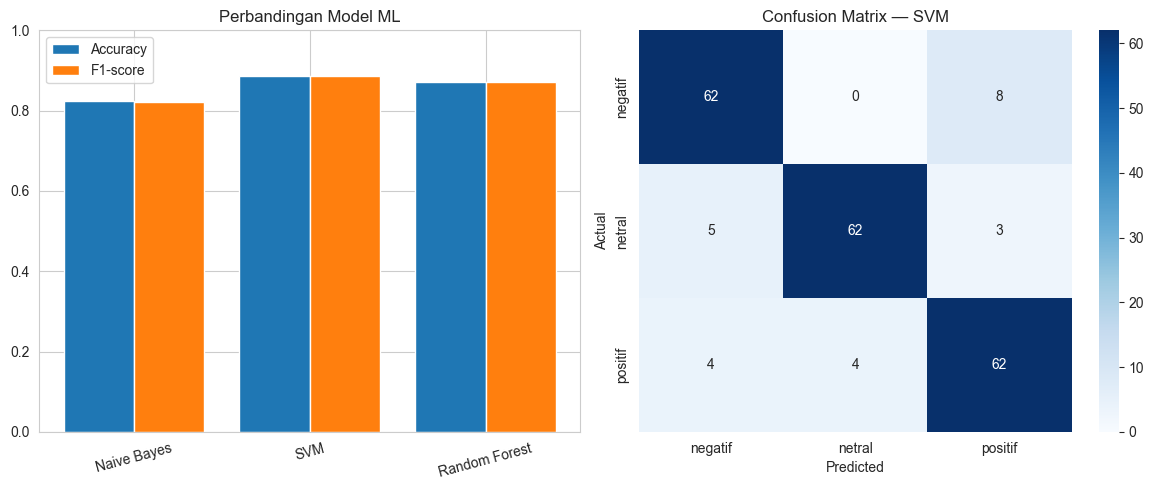

In [7]:
MODEL_GRID = {
    'Naive Bayes': (MultinomialNB(), {'alpha': [0.5, 1.0, 2.0]}),
    'SVM': (SVC(kernel='linear', probability=True, random_state=RANDOM_STATE), {'C': [1, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
                       {'n_estimators': [100, 200], 'max_depth': [None, 20]}),
}

results = {}
for name, (model, params) in MODEL_GRID.items():
    grid = GridSearchCV(model, params, cv=3, scoring='f1_weighted', n_jobs=1)
    grid.fit(X_train_tfidf, y_train)
    best_model = grid.best_estimator_

    y_test_pred = best_model.predict(X_test_tfidf)
    results[name] = {
        'model': best_model,
        'best_params': grid.best_params_,
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred, average='weighted'),
    }
    joblib.dump(best_model, f"model/{name.lower().replace(' ', '_')}.pkl")

    print(f"\n{name} — best params: {grid.best_params_}")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

best_ml_model_name = max(results, key=lambda n: results[n]['test_f1'])
print(f"\nModel ML terbaik: {best_ml_model_name} (F1={results[best_ml_model_name]['test_f1']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(results.keys())
x = np.arange(len(names))
axes[0].bar(x - 0.2, [results[n]['test_accuracy'] for n in names], width=0.4, label='Accuracy')
axes[0].bar(x + 0.2, [results[n]['test_f1'] for n in names], width=0.4, label='F1-score')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
axes[0].set_ylim(0, 1); axes[0].legend(); axes[0].set_title('Perbandingan Model ML')

cm = confusion_matrix(y_test, results[best_ml_model_name]['model'].predict(X_test_tfidf))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title(f'Confusion Matrix — {best_ml_model_name}')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('visualisasi/ml_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Model Deep Learning (BiLSTM)

BiLSTM dipilih supaya konteks kalimat ditangkap dari dua arah (kata sebelum & sesudah),
berguna untuk menangkap negasi/konteks yang sering muncul di ulasan Bahasa Indonesia.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.4884 - loss: 1.0906 - val_accuracy: 0.4476 - val_loss: 1.0764 - learning_rate: 0.0010
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 951ms/step - accuracy: 0.5728 - loss: 1.0186 - val_accuracy: 0.5333 - val_loss: 0.9560 - learning_rate: 0.0010
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6626 - loss: 0.8140 - val_accuracy: 0.5810 - val_loss: 0.8321 - learning_rate: 0.0010
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7565 - loss: 0.6193 - val_accuracy: 0.6952 - val_loss: 0.8143 - learning_rate: 0.0010
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8735 - loss: 0.4603 - val_accuracy: 0.7810 - val_loss: 0.7732 - learning_rate: 0.0010
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9361 - loss: 0.2961 - val_accuracy: 0.8000 - val_loss: 0.7721 - learning_rate: 0.0010
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9619 - loss: 0.1547 - val_accurac

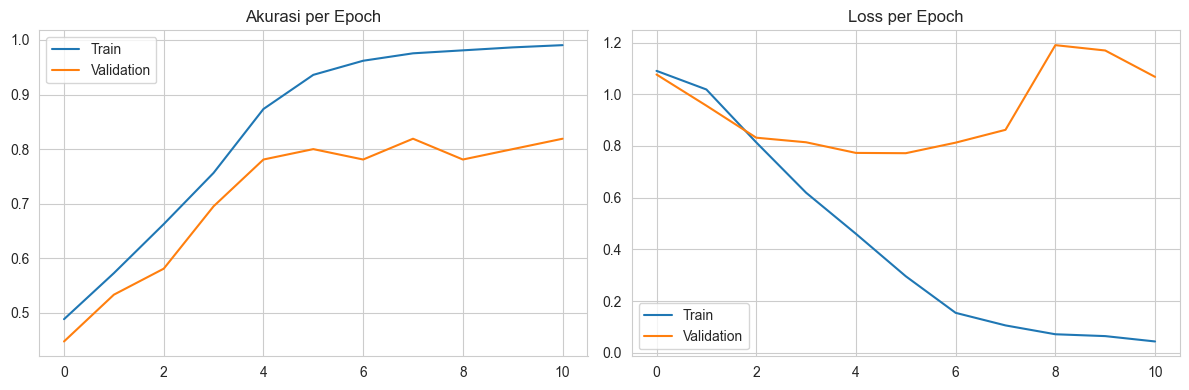

In [8]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

max_length = 150
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='post')
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_length, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding='post')

num_classes = len(label_encoder.classes_)
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

model_bilstm = Sequential([
    Embedding(10000, 128, input_length=max_length, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax'),
])

model_bilstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

model_bilstm.summary()

history = model_bilstm.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15, batch_size=64, callbacks=callbacks, verbose=1,
)

y_test_pred_proba = model_bilstm.predict(X_test_pad, verbose=0)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)
y_test_true = np.argmax(y_test_cat, axis=1)

bilstm_accuracy = accuracy_score(y_test_true, y_test_pred)
bilstm_f1 = f1_score(y_test_true, y_test_pred, average='weighted')
print(f"\nBiLSTM — Test Accuracy: {bilstm_accuracy:.4f} | Test F1: {bilstm_f1:.4f}")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Akurasi per Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss per Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('visualisasi/bilstm_training_history.png', dpi=200, bbox_inches='tight')
plt.show()

model_bilstm.save('model/bilstm_model.h5')
with open('model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

## 9. Evaluasi & Analisis Overfitting

Membandingkan akurasi training vs validation untuk mendeteksi overfitting, lalu melihat
confusion matrix BiLSTM secara lebih detail (mana kelas yang paling sering tertukar).

Training accuracy: 0.9905 | Validation accuracy: 0.8190 | Gap: 0.1714
Indikasi overfitting cukup kuat — pertimbangkan tambah dropout, kurangi kompleksitas model, atau tambah data.


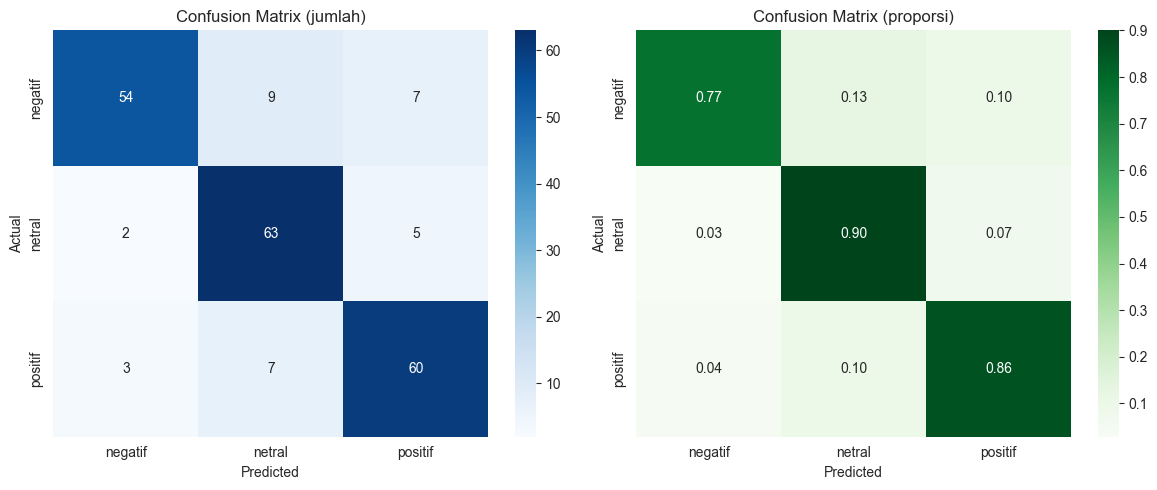

In [9]:
train_acc, val_acc = history.history['accuracy'][-1], history.history['val_accuracy'][-1]
gap = train_acc - val_acc

print(f"Training accuracy: {train_acc:.4f} | Validation accuracy: {val_acc:.4f} | Gap: {gap:.4f}")
if gap > 0.15:
    print("Indikasi overfitting cukup kuat — pertimbangkan tambah dropout, kurangi kompleksitas model, atau tambah data.")
elif gap > 0.08:
    print("Indikasi overfitting ringan — early stopping/regularisasi tambahan bisa membantu.")
else:
    print("Generalisasi cukup baik.")

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (jumlah)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (proporsi)')
for ax in axes:
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('visualisasi/bilstm_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Ensemble Model

Menggabungkan prediksi Naive Bayes, SVM, Random Forest, dan BiLSTM dengan **weighted
voting** (bobot lebih besar untuk SVM & Random Forest, yang biasanya lebih akurat dari
Naive Bayes untuk teks). Semua model yang dipakai di sini masih berada di memori dari
cell-cell sebelumnya, jadi tidak perlu load ulang dari disk.

In [10]:
class EnsembleSentimentAnalyzer:
    """Gabungkan prediksi beberapa model sentimen dengan weighted voting."""
    WEIGHTS = {'Naive Bayes': 0.2, 'SVM': 0.3, 'Random Forest': 0.3, 'BiLSTM': 0.2}

    def __init__(self, ml_models, tfidf, label_encoder, bilstm=None, dl_tokenizer=None, max_length=150):
        self.ml_models = ml_models  # dict: nama -> model sklearn yang sudah di-fit
        self.tfidf = tfidf
        self.label_encoder = label_encoder
        self.bilstm = bilstm
        self.dl_tokenizer = dl_tokenizer
        self.max_length = max_length

    def predict(self, text):
        text_clean = clean_text_for_indobert(text)
        if len(text_clean.split()) < 2:
            return {'sentiment': 'netral', 'confidence': 0.5, 'votes': {}}

        text_tfidf = self.tfidf.transform([text_clean])
        votes = {}

        for name, model in self.ml_models.items():
            proba = model.predict_proba(text_tfidf)[0]
            pred = int(np.argmax(proba))
            votes[name] = (pred, float(proba[pred]))

        if self.bilstm is not None and self.dl_tokenizer is not None:
            seq = pad_sequences(self.dl_tokenizer.texts_to_sequences([text_clean]),
                                 maxlen=self.max_length, padding='post')
            proba = self.bilstm.predict(seq, verbose=0)[0]
            pred = int(np.argmax(proba))
            votes['BiLSTM'] = (pred, float(proba[pred]))

        active_weights = {k: self.WEIGHTS.get(k, 0.25) for k in votes}
        total_weight = sum(active_weights.values())

        scores = {}
        for name, (pred, conf) in votes.items():
            scores[pred] = scores.get(pred, 0) + active_weights[name] * conf

        final_pred = max(scores, key=scores.get)
        final_confidence = scores[final_pred] / total_weight
        sentiment = self.label_encoder.inverse_transform([final_pred])[0]

        return {
            'sentiment': sentiment,
            'confidence': final_confidence,
            'votes': {name: (self.label_encoder.inverse_transform([p])[0], c) for name, (p, c) in votes.items()},
        }


ml_models = {name: results[name]['model'] for name in results}
ensemble = EnsembleSentimentAnalyzer(ml_models, tfidf, label_encoder, bilstm=model_bilstm, dl_tokenizer=tokenizer)

contoh_teks = [
    "Aplikasi Lightroom mobile sangat bagus, preset lengkap dan mudah dipakai!",
    "Sering crash saat export foto, sangat mengecewakan.",
    "Fitur oke tapi harga langganannya lumayan mahal.",
]

for teks in contoh_teks:
    hasil = ensemble.predict(teks)
    print(f"\nTeks: {teks}")
    print(f"Sentimen: {hasil['sentiment'].upper()} (confidence: {hasil['confidence']:.2%})")
    for model_name, (sent, conf) in hasil['votes'].items():
        print(f"   {model_name}: {sent} ({conf:.2%})")


Teks: Aplikasi Lightroom mobile sangat bagus, preset lengkap dan mudah dipakai!
Sentimen: POSITIF (confidence: 94.43%)
   Naive Bayes: positif (91.61%)
   SVM: positif (98.07%)
   Random Forest: positif (89.00%)
   BiLSTM: positif (99.96%)

Teks: Sering crash saat export foto, sangat mengecewakan.
Sentimen: NETRAL (confidence: 36.94%)
   Naive Bayes: netral (44.79%)
   SVM: netral (43.31%)
   Random Forest: positif (62.00%)
   BiLSTM: netral (74.95%)

Teks: Fitur oke tapi harga langganannya lumayan mahal.
Sentimen: NEGATIF (confidence: 66.90%)
   Naive Bayes: negatif (58.79%)
   SVM: negatif (72.59%)
   Random Forest: negatif (49.83%)
   BiLSTM: negatif (92.09%)


> Untuk memakai ensemble ini di luar notebook, tidak perlu pickle seluruh objek
> `EnsembleSentimentAnalyzer` (riskan untuk model Keras di dalamnya) — cukup load ulang
> `tfidf`, `label_encoder`, model ML (`joblib.load`) dan `model_bilstm`
> (`tf.keras.models.load_model`), lalu buat ulang instance-nya seperti di atas. Semua
> file itu sudah tersimpan di folder `model/`.

## 11. Ringkasan Hasil

Angka di bawah dihitung langsung dari hasil run ini (bukan nilai tetap) — akan berubah
setiap kali notebook dijalankan ulang, tergantung data yang ter-scrape.

Tanggal analisis        : 10 September 2026
Total ulasan discraping  : 2224
Total setelah balancing  : 1050

Distribusi sentimen (setelah balancing):
sentiment
netral     350
negatif    350
positif    350
Name: count, dtype: int64

Akurasi model pada test set:
   Naive Bayes    : 0.824
   SVM            : 0.886
   Random Forest  : 0.871
   BiLSTM         : 0.843


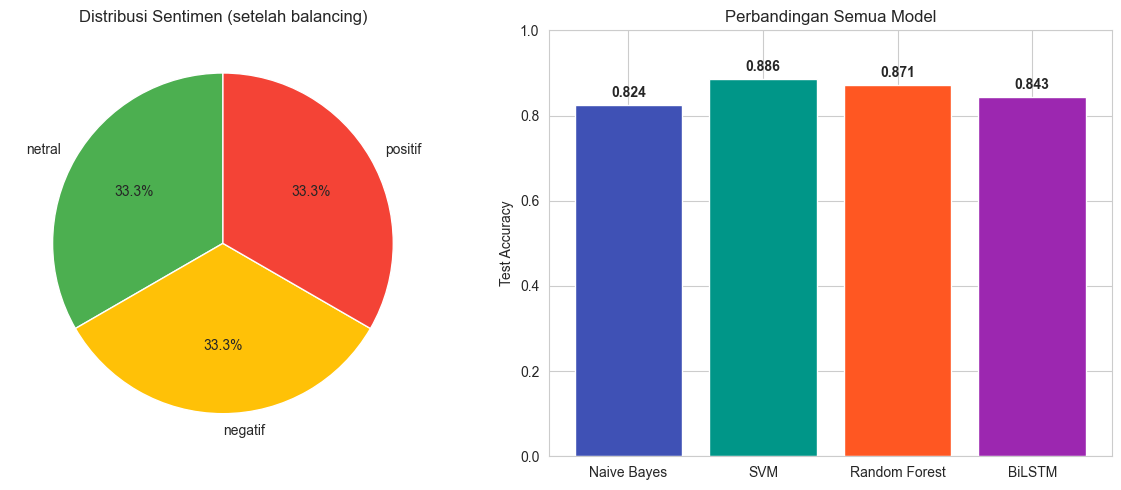

In [11]:
print(f"Tanggal analisis        : {datetime.now().strftime('%d %B %Y')}")
print(f"Total ulasan discraping  : {len(df_raw)}")
print(f"Total setelah balancing  : {len(df_balanced)}")
print()
print("Distribusi sentimen (setelah balancing):")
print(df_balanced['sentiment'].value_counts())
print()
print("Akurasi model pada test set:")
for name in results:
    print(f"   {name:15}: {results[name]['test_accuracy']:.3f}")
print(f"   {'BiLSTM':15}: {bilstm_accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_counts = df_balanced['sentiment'].value_counts()
axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#FFC107', '#F44336'], startangle=90)
axes[0].set_title('Distribusi Sentimen (setelah balancing)')

model_names = list(results.keys()) + ['BiLSTM']
model_accs = [results[n]['test_accuracy'] for n in results] + [bilstm_accuracy]
axes[1].bar(model_names, model_accs, color=['#3F51B5', '#009688', '#FF5722', '#9C27B0'])
axes[1].set_ylim(0, 1); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Perbandingan Semua Model')
for i, acc in enumerate(model_accs):
    axes[1].text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visualisasi/final_summary.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Word Cloud

Kata yang paling sering muncul secara umum, lalu dipecah per sentimen untuk melihat kata
mana yang mencolok di ulasan positif/netral/negatif.

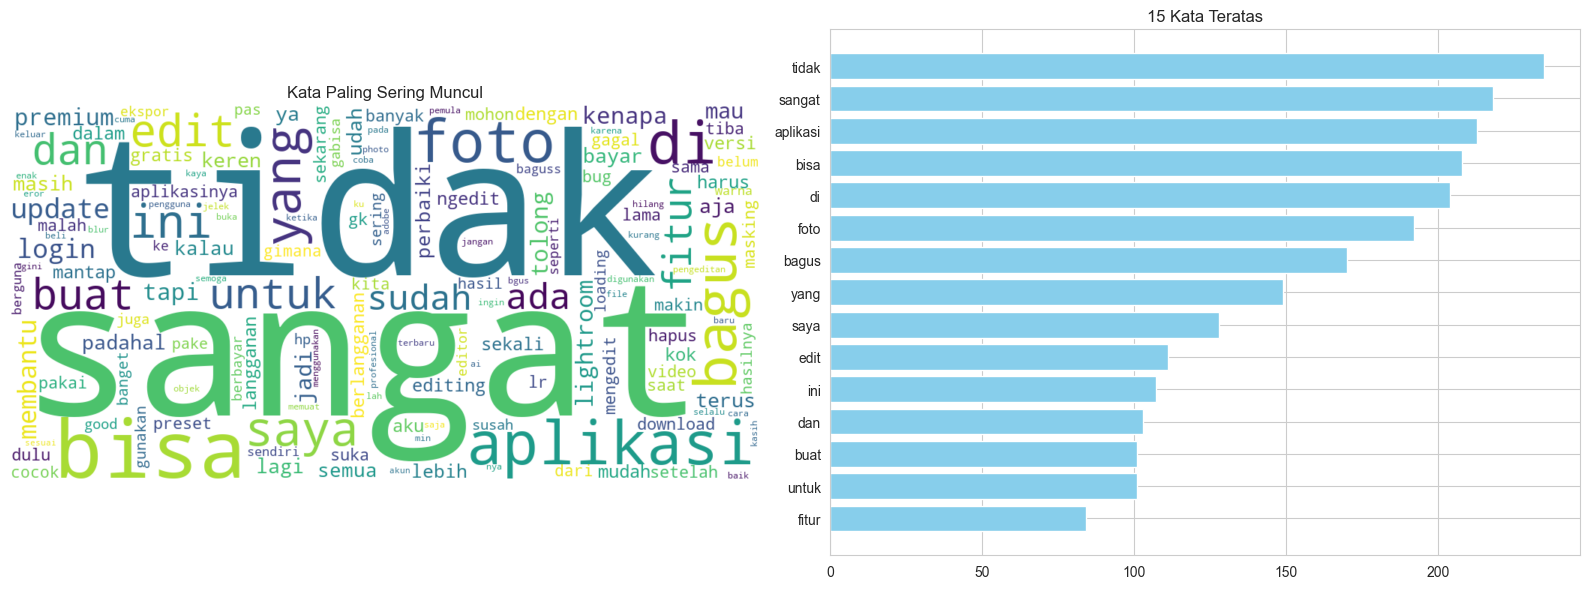

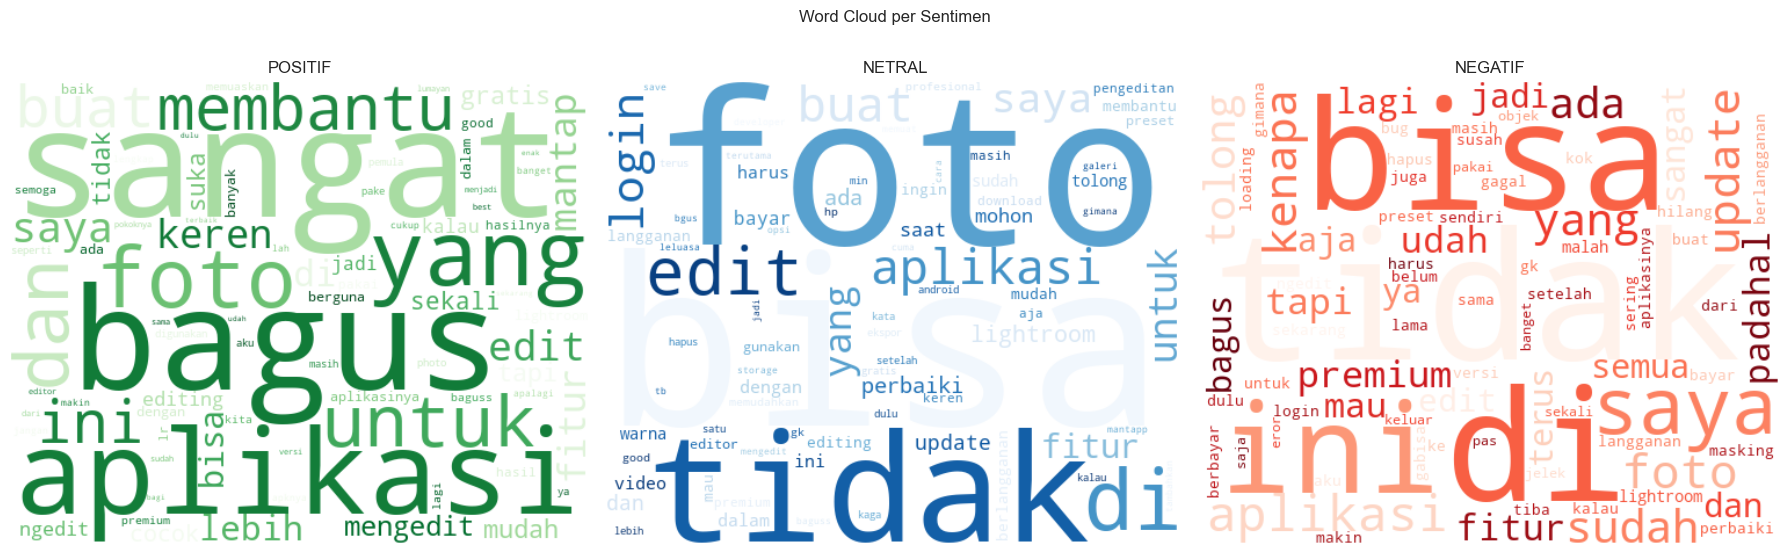

In [12]:
all_text = ' '.join(df_balanced['content_clean'].dropna())

wc_all = WordCloud(width=1000, height=500, background_color='white',
                    max_words=150, collocations=False, colormap='viridis').generate(all_text)
word_freq = Counter(all_text.split()).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].axis('off'); axes[0].set_title('Kata Paling Sering Muncul')

words, counts = zip(*word_freq)
axes[1].barh(range(len(words)), counts, color='skyblue')
axes[1].set_yticks(range(len(words))); axes[1].set_yticklabels(words)
axes[1].invert_yaxis(); axes[1].set_title('15 Kata Teratas')

plt.tight_layout()
plt.savefig('visualisasi/wordcloud_overall.png', dpi=200, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'positif': 'Greens', 'netral': 'Blues', 'negatif': 'Reds'}

for ax, sentiment in zip(axes, ['positif', 'netral', 'negatif']):
    text = ' '.join(df_balanced.loc[df_balanced['sentiment'] == sentiment, 'content_clean'].dropna())
    if text:
        wc = WordCloud(width=500, height=400, background_color='white', max_words=80,
                        collocations=False, colormap=colors[sentiment]).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment.upper())
    ax.axis('off')

plt.suptitle('Word Cloud per Sentimen')
plt.tight_layout()
plt.savefig('visualisasi/wordcloud_per_sentiment.png', dpi=200, bbox_inches='tight')
plt.show()

## 13. Demo Prediksi

Fungsi kecil untuk mencoba ensemble pada kalimat lain — cukup panggil
`predict_and_show("kalimat kamu")` di cell baru. Sengaja tidak dibuat sebagai loop
`input()` interaktif, karena itu akan membuat notebook macet menunggu input kalau
dijalankan lewat "Run All".

Teks     : Preset-nya keren banget, gampang dipakai buat editing sehari-hari.
Sentimen : POSITIF (confidence: 78.40%)
   - Naive Bayes: positif (76.76%)
   - SVM: positif (97.25%)
   - Random Forest: positif (61.47%)
   - BiLSTM: positif (77.18%)

Teks     : Aplikasi lemot dan sering force close pas mau export foto.
Sentimen : NEGATIF (confidence: 34.80%)
   - Naive Bayes: negatif (66.24%)
   - SVM: negatif (71.84%)
   - Random Forest: netral (44.72%)
   - BiLSTM: netral (92.66%)

Teks     : Lumayan buat editing dasar, tapi watermark versi gratis ganggu banget.
Sentimen : POSITIF (confidence: 69.87%)
   - Naive Bayes: positif (73.22%)
   - SVM: positif (95.04%)
   - Random Forest: positif (55.42%)
   - BiLSTM: positif (50.42%)

Teks     : Sudah bagus tapi kok makin lama makin berat ya di hp saya.
Sentimen : NEGATIF (confidence: 87.90%)
   - Naive Bayes: negatif (84.77%)
   - SVM: negatif (94.76%)
   - Random Forest: negatif (75.50%)
   - BiLSTM: negatif (99.36%)



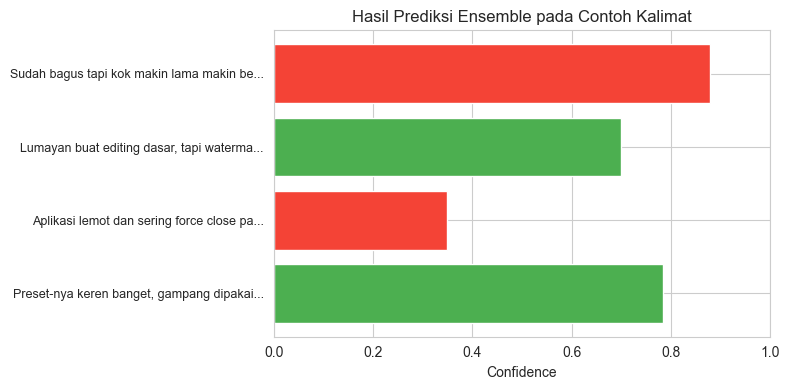

In [13]:
def predict_and_show(text):
    hasil = ensemble.predict(text)
    print(f"Teks     : {text}")
    print(f"Sentimen : {hasil['sentiment'].upper()} (confidence: {hasil['confidence']:.2%})")
    for model_name, (sent, conf) in hasil['votes'].items():
        print(f"   - {model_name}: {sent} ({conf:.2%})")
    print()
    return hasil


# Ganti/tambah kalimat di sini untuk mencoba kasus lain
test_sentences = [
    "Preset-nya keren banget, gampang dipakai buat editing sehari-hari.",
    "Aplikasi lemot dan sering force close pas mau export foto.",
    "Lumayan buat editing dasar, tapi watermark versi gratis ganggu banget.",
    "Sudah bagus tapi kok makin lama makin berat ya di hp saya.",
]

hasil_list = [predict_and_show(t) for t in test_sentences]

fig, ax = plt.subplots(figsize=(8, 4))
colors_map = {'positif': '#4CAF50', 'netral': '#FFC107', 'negatif': '#F44336'}
bar_colors = [colors_map.get(h['sentiment'], 'gray') for h in hasil_list]

ax.barh(range(len(test_sentences)), [h['confidence'] for h in hasil_list], color=bar_colors)
ax.set_yticks(range(len(test_sentences)))
ax.set_yticklabels([f"{s[:40]}..." if len(s) > 40 else s for s in test_sentences], fontsize=9)
ax.set_xlim(0, 1); ax.set_xlabel('Confidence')
ax.set_title('Hasil Prediksi Ensemble pada Contoh Kalimat')
plt.tight_layout()
plt.show()

## Catatan & Kemungkinan Pengembangan

- Label training berasal dari model IndoBERT, bukan anotasi manusia — akurasi model
  akhir jadi ikut dibatasi oleh kualitas model pelabel itu sendiri. Validasi manual pada
  sebagian sampel akan memperkuat hasil untuk kebutuhan yang lebih serius.
- `TARGET_REVIEWS`, `MAX_PER_CLASS`, dan hyperparameter grid di Section 7 semuanya bisa
  diubah langsung di cell terkait untuk eksplorasi lebih lanjut.
- Ide pengembangan lanjutan: fine-tuning IndoBERT langsung (bukan cuma dipakai untuk
  labeling), atau membungkus `EnsembleSentimentAnalyzer` sebagai endpoint API sederhana
  (mis. dengan FastAPI) untuk didemokan secara live.